In [1]:
library(magick)
library(ggplot2)
library(cowplot)

Linking to ImageMagick 7.1.1.2
Enabled features: cairo, fontconfig, freetype, fftw, rsvg, webp, x11
Disabled features: ghostscript, heic, lcms, pango, raw

Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
Warning message:
“package ‘cowplot’ was built under R version 4.2.3”


In [2]:
save_figure_dir <- "./plots/figures/"
if (!dir.exists(save_figure_dir)) {
    dir.create(save_figure_dir, recursive = TRUE)
}

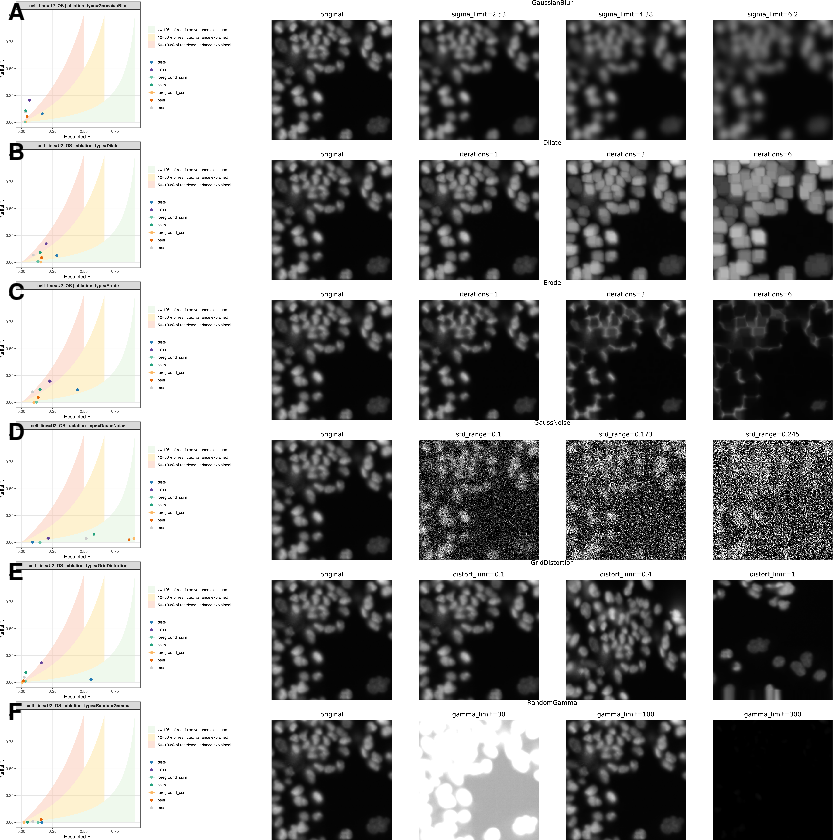

In [3]:
# --------------------------
# Input files
# --------------------------
blur_metric_panel_file <- "./plots/plate2_u2os_nest_confluence_GaussianBlur.pdf"
blur_eg_panel_file     <- "./plots/fig_panels/GaussianBlur_sigma_limit_seed=1.pdf"

dilate_metric_panel_file <- "./plots/plate2_u2os_nest_confluence_Dilate.pdf"
dilate_eg_panel_file     <- "./plots/fig_panels/Dilate_iterations_seed=1.pdf"

erode_metric_panel_file <- "./plots/plate2_u2os_nest_confluence_Erode.pdf"
erode_eg_panel_file     <- "./plots/fig_panels/Erode_iterations_seed=1.pdf"

noise_metric_panel_file <- "./plots/plate2_u2os_nest_confluence_GaussNoise.pdf"
noise_eg_panel_file     <- "./plots/fig_panels/GaussNoise_std_range_seed=1.pdf"

distort_metric_panel_file <- "./plots/plate2_u2os_nest_confluence_GridDistortion.pdf"
distort_eg_panel_file     <- "./plots/fig_panels/GridDistortion_distort_limit_seed=1.pdf"

gamma_metric_panel_file <- "./plots/plate2_u2os_nest_confluence_RandomGamma.pdf"
gamma_eg_panel_file     <- "./plots/fig_panels/RandomGamma_gamma_limit_seed=1.pdf"

# --------------------------
# Helper: read first PDF page, trim, wrap as cowplot drawable
# --------------------------
pdf_panel <- function(file, density = 400) {
  img <- magick::image_read_pdf(file, density = density)[1]
  img <- magick::image_trim(img)
  cowplot::ggdraw() + cowplot::draw_image(img)
}

# --------------------------
# Helper: make one row = metric panel + example panel
# metric panel narrower, example panel wider
# --------------------------
make_pair_row <- function(metric_file, eg_file,
                          metric_rel_width = 2,
                          gap_rel_width = 0.3,
                          eg_rel_width = 5,
                          density = 400) {

  metric_plot <- pdf_panel(metric_file, density = density)
  eg_plot     <- pdf_panel(eg_file, density = density)

  spacer <- cowplot::ggdraw()  # empty plot = gap

  cowplot::plot_grid(
    metric_plot,
    spacer,
    eg_plot,
    nrow = 1,
    rel_widths = c(metric_rel_width, gap_rel_width, eg_rel_width),
    align = "h",
    axis = "tb"
  )
}

# --------------------------
# Build the six rows
# --------------------------
row_blur <- make_pair_row(
  blur_metric_panel_file,
  blur_eg_panel_file
)

row_dilate <- make_pair_row(
  dilate_metric_panel_file,
  dilate_eg_panel_file
)

row_erode <- make_pair_row(
  erode_metric_panel_file,
  erode_eg_panel_file
)

row_noise <- make_pair_row(
  noise_metric_panel_file,
  noise_eg_panel_file
)

row_distort <- make_pair_row(
  distort_metric_panel_file,
  distort_eg_panel_file
)

row_gamma <- make_pair_row(
  gamma_metric_panel_file,
  gamma_eg_panel_file
)

# --------------------------
# Stack rows vertically
# equal row height
# --------------------------
final_fig <- cowplot::plot_grid(
  row_blur,
  row_dilate,
  row_erode,
  row_noise,
  row_distort,
  row_gamma,
  ncol = 1,
  rel_heights = rep(1, 6),
  labels = c("A", "B", "C", "D", "E", "F"),
  label_size = 14,
  label_fontface = "bold",
  label_x = 0.01,
  label_y = 0.98,
  hjust = 0,
  vjust = 1,
  align = "v",
  axis = "lr"
)

final_fig

In [4]:
ggsave(
  paste0(save_figure_dir, "combined_ablation_panels.pdf"),
  final_fig,
  width = 16,
  height = 24,
  device = cairo_pdf,
  bg = "white"
)